# Analyse Data

In [ ]:
"""Analyse Data Used to Fine-Tune scGPT model

Structure:
    1. Imports, Variables, Functions
    2. Load Data
    3. Exploratory Analysis
"""

# 1. Imports, Variables, Functions
# imports
import sys
import os, numpy as np
import json
import h5py, scanpy as sc
sys.path.append("../..")
from src.utils import io 
import pandas as pd
from src.utils import viz as vz
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib import cm



# variables
run_dir = os.path.join("..","..","outputs","run-25-08-18-03")

# functions
def plot_tsne_adata(adata: sc.AnnData, label: str) -> None:

    def _fill_nans(X):
        X[np.isnan(adata.X)] = 0
        return X


    # get raw gene expression
    X = np.array(adata.X).copy()

    # fill nans
    X = _fill_nans(X)

    # compute t-SNE on expression matrix
    X = TSNE(n_components=2, random_state=42).fit_transform(X)

    # get colors for labels
    lab = adata.obs[label]
    if not pd.api.types.is_categorical_dtype(lab):
        lab = lab.astype("category")

    codes = lab.cat.codes.to_numpy()
    cats  = lab.cat.categories.to_list()
    cmap = cm.get_cmap("tab20", len(cats)) if len(cats) <= 20 else cm.get_cmap("gist_rainbow", len(cats))

    # plot 
    plt.figure(figsize=(5,5))   
    sc_plot = plt.scatter(X[:,0], X[:,1],
                          c=codes, cmap=cmap, s=8, alpha=0.7)

    plt.title(f"t-SNE colored by {label}")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.tight_layout()
    
    # remove legend
    if len(cats) <= 20:
        cbar = plt.colorbar(sc_plot, ticks=range(len(cats)))
        cbar.ax.set_yticklabels(cats)
    plt.show()


# 2. Load Data
(
    _,
    _,
    _,
    _,
    _,
    _,
    _,
    _,
    _,
    _,
    _,
    _,
    adata,
    _,
    _,
    _,
) = io.load_run_output(run_dir)

X = np.array(adata.X)

# 3. Exploratory Analysis

# how many samples
n_disease_samples = adata[adata.obs["disease"] != "Control"].shape[0]
n_control_samples = adata[adata.obs["disease"] == "Control"].shape[0]

# how many samples per library stratergy
n_rna_seq_samples = adata[adata.obs["library"] == "RNA-Seq"].shape[0]
n_ma_seq_samples = adata[adata.obs["library"] == "microarray"].shape[0]


# how many genes
n_genes = 3501-np.isnan(X).sum(axis=0)

# how many datasets
n_datasets = adata.obs['dataset'].nunique()

# how many diseases
n_diseases = adata[adata.obs["disease"] != "Control"].obs['do_id'].nunique()

# how many samples per disease
n_samples_per_disease = adata[adata.obs["disease"] != "Control"].obs['do_id'].value_counts().values

# how many samples per dataset
n_samples_per_dataset = adata.obs['dataset'].value_counts().values

df_expl = pd.DataFrame({
    "Nº Datasets": [n_datasets],
    "Nº Diseases": [n_diseases],
    "Nº Samples Disease": [n_disease_samples],
    "Nº Samples Control": [n_control_samples],
    "Nº Samples RNA-Seq": [n_rna_seq_samples],
    "Nº Samples Microarray": [n_ma_seq_samples],
    "Nº Samples per Disease": [f"{np.mean(n_samples_per_disease):.0f} ± {np.std(n_samples_per_disease):.0f}"],
    "Nº Samples per Dataset": [f"{np.mean(n_samples_per_dataset):.0f} ± {np.std(n_samples_per_dataset):.0f}"],
    "Nº Genes per Sample": [f"{np.mean(n_genes):.0f} ± {np.std(n_genes):.0f}"],

})

Nº of loaded variables 16


In [78]:
# dataframe exploration
df_expl.T

,0
Nº Datasets,652
Nº Diseases,131
Nº Samples Disease,20944
Nº Samples Control,0
Nº Samples RNA-Seq,20944
Nº Samples Microarray,0
Nº Samples per Disease,160 ± 235
Nº Samples per Dataset,32 ± 93
Nº Genes per Sample,3495 ± 4


In [ ]:
# viz top families
vz.plot_adata_top_families(adata)

<function src.utils.viz.plot_adata_top_families(adata)>

In [81]:
adata.obs["dsaid"]

4        DSA00004
5        DSA00004
6        DSA00004
7        DSA00004
8        DSA00004
           ...   
35621    DSA10149
35622    DSA10149
35623    DSA10149
35624    DSA10149
35625    DSA10149
Name: dsaid, Length: 20944, dtype: category
Categories (1146, object): ['DSA00004', 'DSA00006', 'DSA00015', 'DSA00016', ..., 'DSA10121', 'DSA10131', 'DSA10132', 'DSA10149']

In [87]:
from src.utils import utils as ut
df_info = ut.load_dsa_info()
dsaid_2_tissue = dict(zip(df_info["dsaid"], df_info["tissue"]))


adata.obs["tissue"] = adata.obs["dsaid"].map(dsaid_2_tissue)


In [90]:
# replace nans
adata.obs["tissue"].fillna("unknown", inplace=True)

/tmp/ipykernel_919456/2229875925.py:21: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(lab):
/tmp/ipykernel_919456/2229875925.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(cats)) if len(cats) <= 20 else cm.get_cmap("gist_rainbow", len(cats))


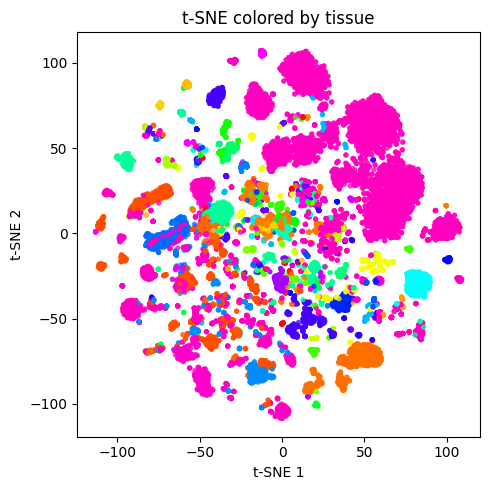

In [91]:
plot_tsne_adata(adata, "tissue")

/tmp/ipykernel_919456/2229875925.py:21: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(lab):
/tmp/ipykernel_919456/2229875925.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(cats)) if len(cats) <= 20 else cm.get_cmap("gist_rainbow", len(cats))


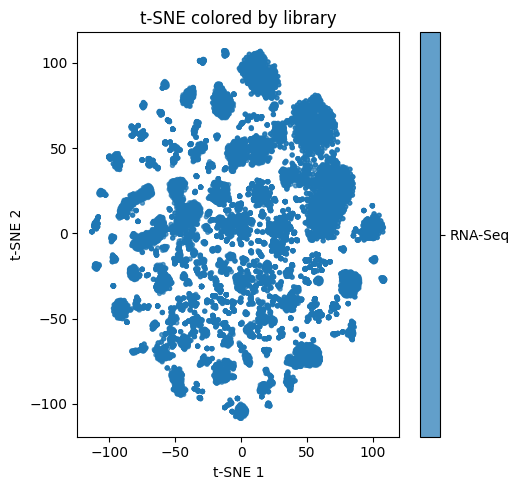

In [ ]:
plot_tsne_adata(adata, "library")

/tmp/ipykernel_919456/2229875925.py:21: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(lab):
/tmp/ipykernel_919456/2229875925.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(cats)) if len(cats) <= 20 else cm.get_cmap("gist_rainbow", len(cats))


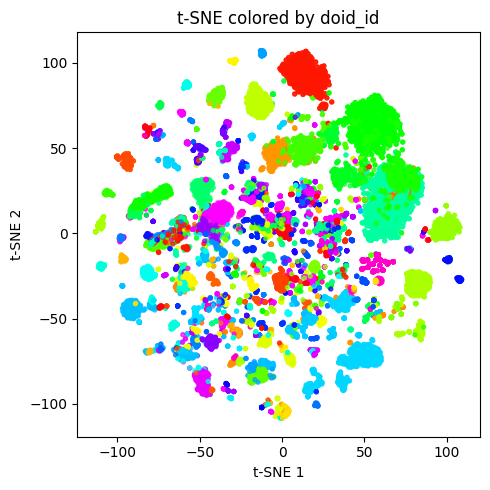

In [ ]:
plot_tsne_adata(adata, "doid_id")

/tmp/ipykernel_919456/2229875925.py:21: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(lab):
/tmp/ipykernel_919456/2229875925.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(cats)) if len(cats) <= 20 else cm.get_cmap("gist_rainbow", len(cats))


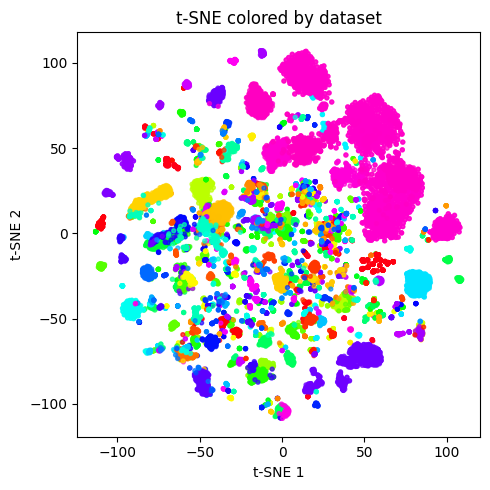

In [ ]:
plot_tsne_adata(adata, "dataset")